# Streaming Pipeline Dashboard

Comprehensive visualization and analysis of the streaming pipeline metrics:
- Traffic metrics (reviews/min, avg stars)
- Sketch accuracy (FM estimates vs exact, Bloom precision/recall)
- Performance metrics (throughput, latency)
- Storage tracking (checkpoint sizes)
- Targeted filtering comparison (All vs High-rated ≥4 stars)

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8")

# Find project root: notebook is in notebooks/, delta/ is in project root
if "__file__" in globals():
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
else:
    # In Jupyter, Path.cwd() might be notebooks/ or project root
    cwd = Path.cwd()
    if cwd.name == "notebooks":
        PROJECT_ROOT = cwd.parent
    elif (cwd / "delta").exists():
        PROJECT_ROOT = cwd
    else:
        # Try going up one level
        parent = cwd.parent
        if (parent / "delta").exists():
            PROJECT_ROOT = parent
        else:
            PROJECT_ROOT = cwd  # Fallback

DELTA_DIR = PROJECT_ROOT / "delta"

# Helper function to safely load parquet data
def load_parquet_safe(path, default=None):
    """Load parquet data if it exists, otherwise return default."""
    if path.exists() and list(path.glob("*.parquet")):
        try:
            return pd.read_parquet(path)
        except Exception as e:
            print(f"Warning: Could not load {path}: {e}")
            return default
    return default

In [2]:
# Load all available metrics
print("Loading metrics data...")

# Traffic metrics
metrics_all = load_parquet_safe(DELTA_DIR / "metrics_1m")
metrics_high_rated = load_parquet_safe(DELTA_DIR / "metrics_1m_high_rated")

# Duplicate metrics
dup_metrics_all = load_parquet_safe(DELTA_DIR / "gold_dup_rate_1m")
dup_metrics_high_rated = load_parquet_safe(DELTA_DIR / "gold_dup_rate_1m_high_rated")

# FM distinct users
fm_all = load_parquet_safe(DELTA_DIR / "fm_distinct_users")
fm_high_rated = load_parquet_safe(DELTA_DIR / "fm_distinct_users_high_rated")

# Performance metrics
perf_all = load_parquet_safe(DELTA_DIR / "performance_metrics")
perf_high_rated = load_parquet_safe(DELTA_DIR / "performance_metrics_high_rated")

# Storage metrics
storage = load_parquet_safe(DELTA_DIR / "storage_metrics")

# Accuracy summaries
fm_accuracy_all = load_parquet_safe(DELTA_DIR / "accuracy_fm_summary")
fm_accuracy_high_rated = load_parquet_safe(DELTA_DIR / "accuracy_fm_summary_high_rated")
bloom_accuracy_all = load_parquet_safe(DELTA_DIR / "accuracy_bloom_summary")
bloom_accuracy_high_rated = load_parquet_safe(DELTA_DIR / "accuracy_bloom_summary_high_rated")

# Debug: Print accuracy data info
if fm_accuracy_all is not None:
    print(f"  FM accuracy (all): {len(fm_accuracy_all)} rows loaded")
if bloom_accuracy_all is not None:
    print(f"  Bloom accuracy (all): {len(bloom_accuracy_all)} rows loaded")

# Process timestamps
for df in [metrics_all, metrics_high_rated, dup_metrics_all, dup_metrics_high_rated, 
           fm_all, fm_high_rated, perf_all, perf_high_rated, storage]:
    if df is not None and "window_start" in df.columns:
        df["window_start"] = pd.to_datetime(df["window_start"])
    if df is not None and "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"])

print("Data loading complete!")
print("\nData availability:")
print(f"  Metrics (all): {'✓' if metrics_all is not None else '✗'}")
print(f"  Metrics (high-rated): {'✓' if metrics_high_rated is not None else '✗'}")
print(f"  Duplicate metrics (all): {'✓' if dup_metrics_all is not None else '✗'}")
print(f"  FM distinct users (all): {'✓' if fm_all is not None else '✗'} (Note: Windows must be 2+ min old to be finalized)")
print(f"  Performance metrics (all): {'✓' if perf_all is not None else '✗'}")
print(f"  Storage metrics: {'✓' if storage is not None else '✗'}")

# Debug: Check if FM checkpoint exists (indicates FM tracker is running)
fm_ckpt = DELTA_DIR / "_ckpt_fm_v1"
if fm_ckpt.exists():
    print(f"\n  FM checkpoint exists: ✓ (FM tracker is configured)")
    print(f"    Checkpoint path: {fm_ckpt}")
else:
    print(f"\n  FM checkpoint missing: ✗")
    print(f"    This means the FM tracker hasn't started yet.")
    print(f"    Make sure spark/stream_reviews.py is running with the latest code.")

Loading metrics data...
  FM accuracy (all): 4 rows loaded
  Bloom accuracy (all): 5 rows loaded
Data loading complete!

Data availability:
  Metrics (all): ✓
  Metrics (high-rated): ✓
  Duplicate metrics (all): ✓
  FM distinct users (all): ✓ (Note: Windows must be 2+ min old to be finalized)
  Performance metrics (all): ✓
  Storage metrics: ✓

  FM checkpoint exists: ✓ (FM tracker is configured)
    Checkpoint path: /Users/andreah/Documents/GitHub/228_Project/delta/_ckpt_fm_v1


In [3]:
# Summary Statistics
print("=" * 60)
print("PIPELINE SUMMARY STATISTICS")
print("=" * 60)

if metrics_all is not None:
    print(f"\n📊 Traffic Metrics (All Reviews):")
    print(f"  Total windows: {len(metrics_all):,}")
    print(f"  Total reviews: {metrics_all['n_reviews'].sum():,}")
    print(f"  Avg reviews/min: {metrics_all['n_reviews'].mean():.1f}")
    print(f"  Avg stars: {metrics_all['avg_stars'].mean():.2f}")

if metrics_high_rated is not None:
    print(f"\n⭐ High-Rated (≥4 stars) Metrics:")
    print(f"  Total windows: {len(metrics_high_rated):,}")
    print(f"  Total reviews: {metrics_high_rated['n_reviews'].sum():,}")
    print(f"  Avg reviews/min: {metrics_high_rated['n_reviews'].mean():.1f}")
    print(f"  Avg stars: {metrics_high_rated['avg_stars'].mean():.2f}")

if dup_metrics_all is not None:
    print(f"\n🔍 Duplicate Detection (All):")
    print(f"  Avg duplicate rate: {dup_metrics_all['dup_rate'].mean():.2%}")
    print(f"  Total duplicates flagged: {dup_metrics_all['dup_count'].sum():,}")

if fm_all is not None:
    fm_with_exact = fm_all[fm_all["distinct_users_exact"].notna()]
    if len(fm_with_exact) > 0:
        print(f"\n👥 Distinct Users (FM, All):")
        print(f"  Windows with exact counts: {len(fm_with_exact)}")
        print(f"  Avg estimate: {fm_with_exact['distinct_users_estimate'].mean():.1f}")
        print(f"  Avg exact: {fm_with_exact['distinct_users_exact'].mean():.1f}")
        if "error_percent" in fm_with_exact.columns:
            avg_error = fm_with_exact["error_percent"].mean()
            print(f"  Avg relative error: {avg_error:.2%}")

if perf_all is not None:
    print(f"\n⚡ Performance (All):")
    print(f"  Avg throughput: {perf_all['avg_throughput'].mean():.1f} events/sec")
    print(f"  Avg latency: {perf_all['avg_latency'].mean():.2f} seconds")

print("\n" + "=" * 60)

PIPELINE SUMMARY STATISTICS

📊 Traffic Metrics (All Reviews):
  Total windows: 247
  Total reviews: 247
  Avg reviews/min: 1.0
  Avg stars: 3.79

⭐ High-Rated (≥4 stars) Metrics:
  Total windows: 103
  Total reviews: 103
  Avg reviews/min: 1.0
  Avg stars: 4.61

🔍 Duplicate Detection (All):
  Avg duplicate rate: 0.91%
  Total duplicates flagged: 27

👥 Distinct Users (FM, All):
  Windows with exact counts: 6
  Avg estimate: 151.5
  Avg exact: 151.5
  Avg relative error: 81.92%

⚡ Performance (All):
  Avg throughput: 3.6 events/sec
  Avg latency: 28802.91 seconds



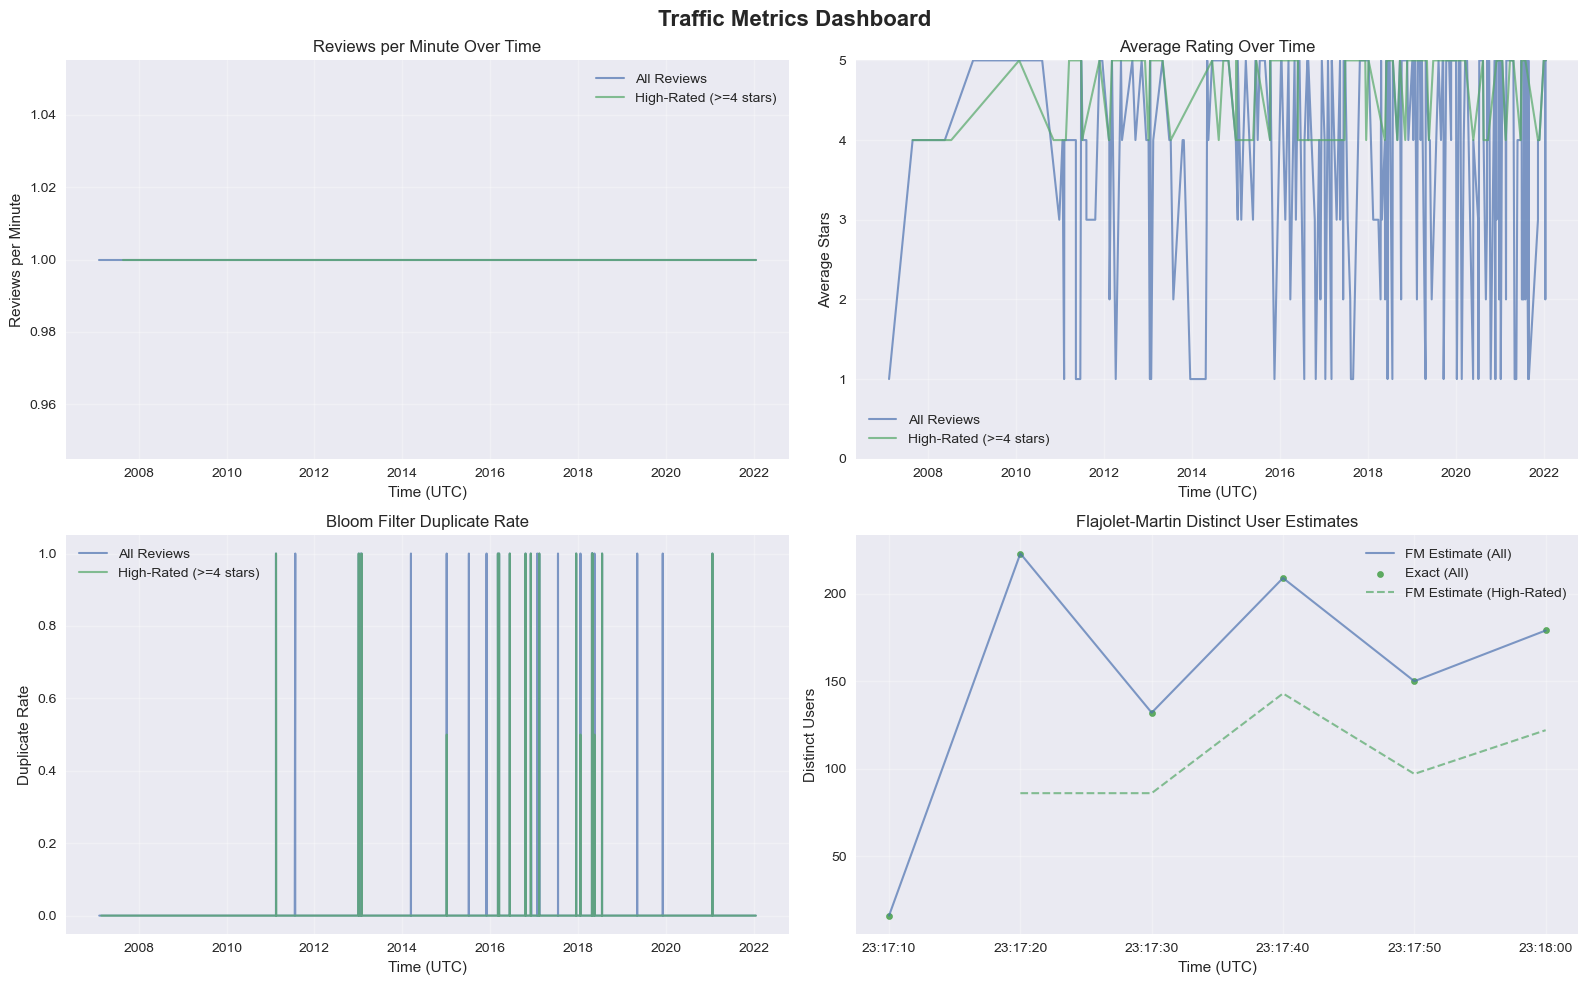

In [4]:
# Dashboard: Traffic Metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Traffic Metrics Dashboard", fontsize=16, fontweight="bold")

# Reviews per minute
ax = axes[0, 0]
if metrics_all is not None:
    metrics_all_sorted = metrics_all.sort_values("window_start")
    ax.plot(
        metrics_all_sorted["window_start"],
        metrics_all_sorted["n_reviews"],
        label="All Reviews",
        alpha=0.7,
        linewidth=1.5,
    )
if metrics_high_rated is not None:
    metrics_high_rated_sorted = metrics_high_rated.sort_values("window_start")
    ax.plot(
        metrics_high_rated_sorted["window_start"],
        metrics_high_rated_sorted["n_reviews"],
        label="High-Rated (>=4 stars)",
        alpha=0.7,
        linewidth=1.5,
    )
ax.set_ylabel("Reviews per Minute")
ax.set_xlabel("Time (UTC)")
ax.set_title("Reviews per Minute Over Time")
ax.legend()
ax.grid(True, alpha=0.3)

# Average stars
ax = axes[0, 1]
if metrics_all is not None:
    ax.plot(
        metrics_all_sorted["window_start"],
        metrics_all_sorted["avg_stars"],
        label="All Reviews",
        alpha=0.7,
        linewidth=1.5,
    )
if metrics_high_rated is not None:
    ax.plot(
        metrics_high_rated_sorted["window_start"],
        metrics_high_rated_sorted["avg_stars"],
        label="High-Rated (>=4 stars)",
        alpha=0.7,
        linewidth=1.5,
    )
ax.set_ylabel("Average Stars")
ax.set_xlabel("Time (UTC)")
ax.set_title("Average Rating Over Time")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 5)

# Duplicate rate
ax = axes[1, 0]
if dup_metrics_all is not None:
    dup_all_sorted = dup_metrics_all.sort_values("window_start")
    ax.plot(
        dup_all_sorted["window_start"],
        dup_all_sorted["dup_rate"],
        label="All Reviews",
        alpha=0.7,
        linewidth=1.5,
    )
if dup_metrics_high_rated is not None:
    dup_high_rated_sorted = dup_metrics_high_rated.sort_values("window_start")
    ax.plot(
        dup_high_rated_sorted["window_start"],
        dup_high_rated_sorted["dup_rate"],
        label="High-Rated (>=4 stars)",
        alpha=0.7,
        linewidth=1.5,
    )
ax.set_ylabel("Duplicate Rate")
ax.set_xlabel("Time (UTC)")
ax.set_title("Bloom Filter Duplicate Rate")
ax.legend()
ax.grid(True, alpha=0.3)

# Distinct users (FM estimate)
ax = axes[1, 1]
if fm_all is not None and len(fm_all) > 0:
    fm_all_sorted = fm_all.sort_values("window_start")
    ax.plot(
        fm_all_sorted["window_start"],
        fm_all_sorted["distinct_users_estimate"],
        label="FM Estimate (All)",
        alpha=0.7,
        linewidth=1.5,
    )
    fm_with_exact = fm_all_sorted[fm_all_sorted["distinct_users_exact"].notna()]
    if len(fm_with_exact) > 0:
        ax.scatter(
            fm_with_exact["window_start"],
            fm_with_exact["distinct_users_exact"],
            label="Exact (All)",
            alpha=0.6,
            s=20,
            color="green",
        )
if fm_high_rated is not None and len(fm_high_rated) > 0:
    fm_hr_sorted = fm_high_rated.sort_values("window_start")
    ax.plot(
        fm_hr_sorted["window_start"],
        fm_hr_sorted["distinct_users_estimate"],
        label="FM Estimate (High-Rated)",
        alpha=0.7,
        linewidth=1.5,
        linestyle="--",
    )
if (fm_all is None or len(fm_all) == 0) and (fm_high_rated is None or len(fm_high_rated) == 0):
    ax.text(
        0.5,
        0.5,
        "FM data not available yet.\nWindows need to be 2+ minutes old\nto be finalized and written.",
        ha="center",
        va="center",
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )
ax.set_ylabel("Distinct Users")
ax.set_xlabel("Time (UTC)")
ax.set_title("Flajolet-Martin Distinct User Estimates")
if (fm_all is not None and len(fm_all) > 0) or (fm_high_rated is not None and len(fm_high_rated) > 0):
    ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


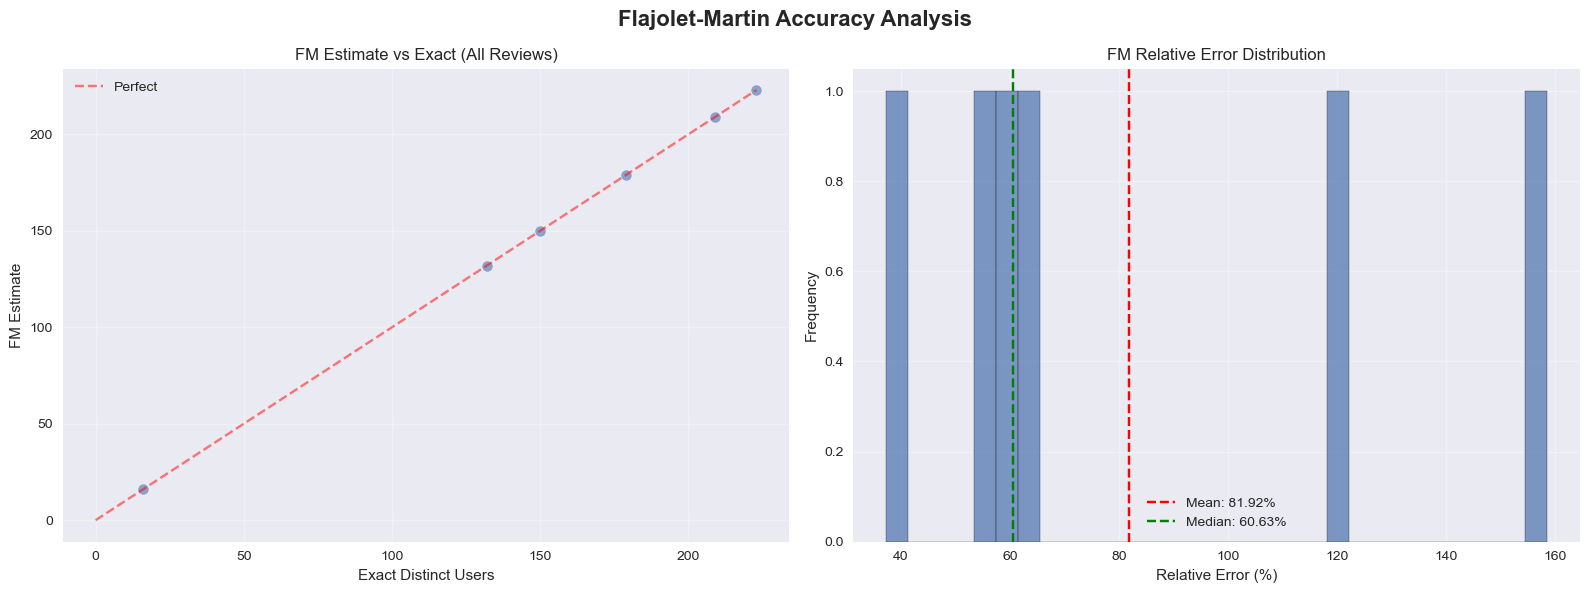

In [5]:
# Dashboard: FM Accuracy (Estimate vs Exact)
if fm_all is not None:
    fm_with_exact = fm_all[fm_all["distinct_users_exact"].notna()].copy()
    
    if len(fm_with_exact) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle("Flajolet-Martin Accuracy Analysis", fontsize=16, fontweight="bold")
        
        # Scatter: Estimate vs Exact
        ax = axes[0]
        ax.scatter(fm_with_exact["distinct_users_exact"], 
                  fm_with_exact["distinct_users_estimate"],
                  alpha=0.6, s=50)
        # Perfect line
        max_val = max(fm_with_exact["distinct_users_exact"].max(), 
                     fm_with_exact["distinct_users_estimate"].max())
        ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label="Perfect")
        ax.set_xlabel("Exact Distinct Users")
        ax.set_ylabel("FM Estimate")
        ax.set_title("FM Estimate vs Exact (All Reviews)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Error distribution
        ax = axes[1]
        if "error_percent" in fm_with_exact.columns:
            errors = fm_with_exact["error_percent"].dropna() * 100
            ax.hist(errors, bins=30, alpha=0.7, edgecolor="black")
            ax.axvline(errors.mean(), color="red", linestyle="--", 
                      label=f"Mean: {errors.mean():.2f}%")
            ax.axvline(errors.median(), color="green", linestyle="--", 
                      label=f"Median: {errors.median():.2f}%")
            ax.set_xlabel("Relative Error (%)")
            ax.set_ylabel("Frequency")
            ax.set_title("FM Relative Error Distribution")
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("No windows with exact counts available for FM accuracy analysis")
else:
    print("FM data not available")


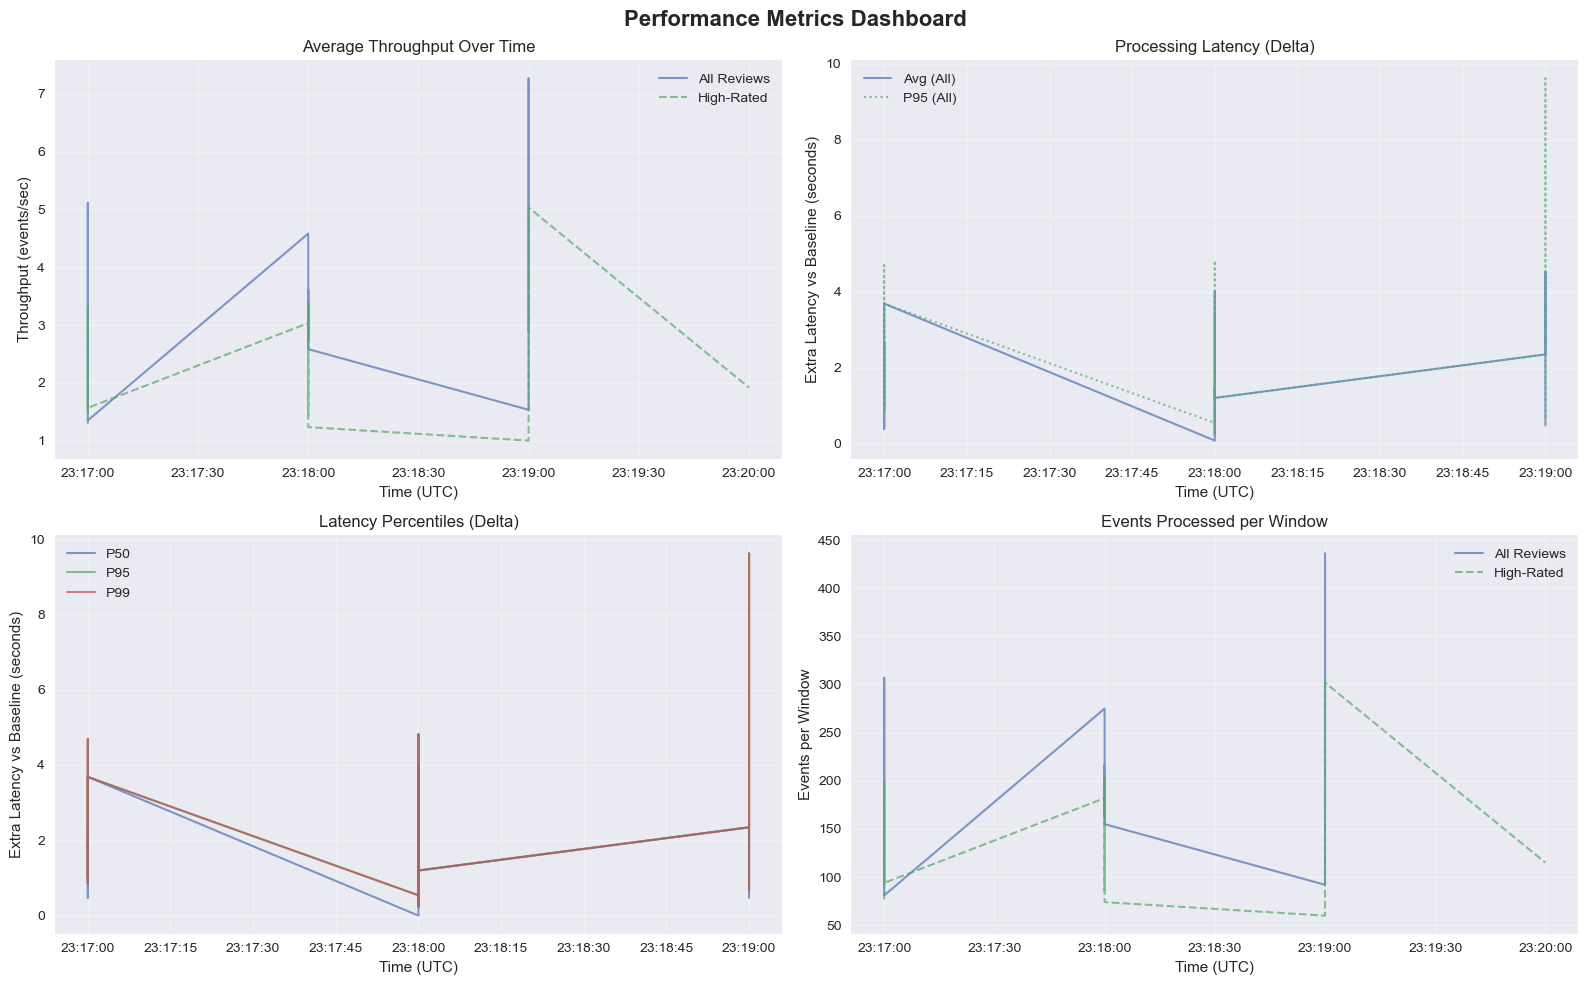

In [13]:
# Dashboard: Performance Metrics
if perf_all is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Performance Metrics Dashboard", fontsize=16, fontweight="bold")

    perf_all_sorted = perf_all.sort_values("window_start")

    # --- Compute baseline-adjusted latency deltas ---
    latency_cols = [c for c in ["avg_latency", "p50_latency", "p95_latency", "p99_latency"] if c in perf_all_sorted.columns]

    latency_min = None
    if latency_cols:
        col_mins = [perf_all_sorted[c].min() for c in latency_cols if perf_all_sorted[c].notna().any()]
        if col_mins:
            latency_min = min(col_mins)

    if latency_min is None:
        latency_min = 0.0

    # Compute deltas (seconds above baseline)
    for col in latency_cols:
        perf_all_sorted[f"{col}_delta"] = perf_all_sorted[col] - latency_min

    perf_hr_sorted = None
    if perf_high_rated is not None:
        perf_hr_sorted = perf_high_rated.sort_values("window_start")
        for col in latency_cols:
            if col in perf_hr_sorted.columns:
                perf_hr_sorted[f"{col}_delta"] = perf_hr_sorted[col] - latency_min

    # Decide display unit based on largest delta
    delta_cols_all = [f"{c}_delta" for c in latency_cols]
    max_delta = 0.0
    for col in delta_cols_all:
        if col in perf_all_sorted.columns and perf_all_sorted[col].notna().any():
            max_delta = max(max_delta, perf_all_sorted[col].max())
        if perf_hr_sorted is not None and col in perf_hr_sorted.columns and perf_hr_sorted[col].notna().any():
            max_delta = max(max_delta, perf_hr_sorted[col].max())

    if max_delta < 1.0:
        latency_scale = 1000.0
        latency_unit = "ms"
    elif max_delta < 60.0:
        latency_scale = 1.0
        latency_unit = "seconds"
    elif max_delta < 3600.0:
        latency_scale = 60.0
        latency_unit = "minutes"
    else:
        latency_scale = 3600.0
        latency_unit = "hours"

    # Create scaled latency delta columns for plotting
    for col in latency_cols:
        delta_col = f"{col}_delta"
        plot_col = f"{col}_plot"
        if delta_col in perf_all_sorted.columns:
            perf_all_sorted[plot_col] = perf_all_sorted[delta_col] * (1.0 / latency_scale)
        if perf_hr_sorted is not None and delta_col in perf_hr_sorted.columns:
            perf_hr_sorted[plot_col] = perf_hr_sorted[delta_col] * (1.0 / latency_scale)

    # Throughput
    ax = axes[0, 0]
    ax.plot(perf_all_sorted["window_start"], perf_all_sorted["avg_throughput"],
            label="All Reviews", alpha=0.7, linewidth=1.5)
    if perf_hr_sorted is not None:
        ax.plot(perf_hr_sorted["window_start"], perf_hr_sorted["avg_throughput"],
                label="High-Rated", alpha=0.7, linewidth=1.5, linestyle="--")
    ax.set_ylabel("Throughput (events/sec)")
    ax.set_xlabel("Time (UTC)")
    ax.set_title("Average Throughput Over Time")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Latency (avg)
    ax = axes[0, 1]
    if "avg_latency_plot" in perf_all_sorted.columns:
        ax.plot(perf_all_sorted["window_start"], perf_all_sorted["avg_latency_plot"],
                label="Avg (All)", alpha=0.7, linewidth=1.5)
    if "p95_latency_plot" in perf_all_sorted.columns:
        ax.plot(perf_all_sorted["window_start"], perf_all_sorted["p95_latency_plot"],
                label="P95 (All)", alpha=0.7, linewidth=1.5, linestyle=":")
    ax.set_ylabel(f"Extra Latency vs Baseline ({latency_unit})")
    ax.set_xlabel("Time (UTC)")
    ax.set_title("Processing Latency (Delta)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Latency distribution (if available)
    ax = axes[1, 0]
    any_latency = False
    if "p50_latency_plot" in perf_all_sorted.columns:
        ax.plot(perf_all_sorted["window_start"], perf_all_sorted["p50_latency_plot"],
                label="P50", alpha=0.7, linewidth=1.5)
        any_latency = True
    if "p95_latency_plot" in perf_all_sorted.columns:
        ax.plot(perf_all_sorted["window_start"], perf_all_sorted["p95_latency_plot"],
                label="P95", alpha=0.7, linewidth=1.5)
        any_latency = True
    if "p99_latency_plot" in perf_all_sorted.columns:
        ax.plot(perf_all_sorted["window_start"], perf_all_sorted["p99_latency_plot"],
                label="P99", alpha=0.7, linewidth=1.5)
        any_latency = True
    if any_latency:
        ax.set_ylabel(f"Extra Latency vs Baseline ({latency_unit})")
        ax.set_xlabel("Time (UTC)")
        ax.set_title("Latency Percentiles (Delta)")
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Total events processed
    ax = axes[1, 1]
    if "total_events" in perf_all_sorted.columns:
        ax.plot(perf_all_sorted["window_start"], perf_all_sorted["total_events"],
                label="All Reviews", alpha=0.7, linewidth=1.5)
        if perf_hr_sorted is not None and "total_events" in perf_hr_sorted.columns:
            ax.plot(perf_hr_sorted["window_start"], perf_hr_sorted["total_events"],
                    label="High-Rated", alpha=0.7, linewidth=1.5, linestyle="--")
        ax.set_ylabel("Events per Window")
        ax.set_xlabel("Time (UTC)")
        ax.set_title("Events Processed per Window")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Performance metrics not available")


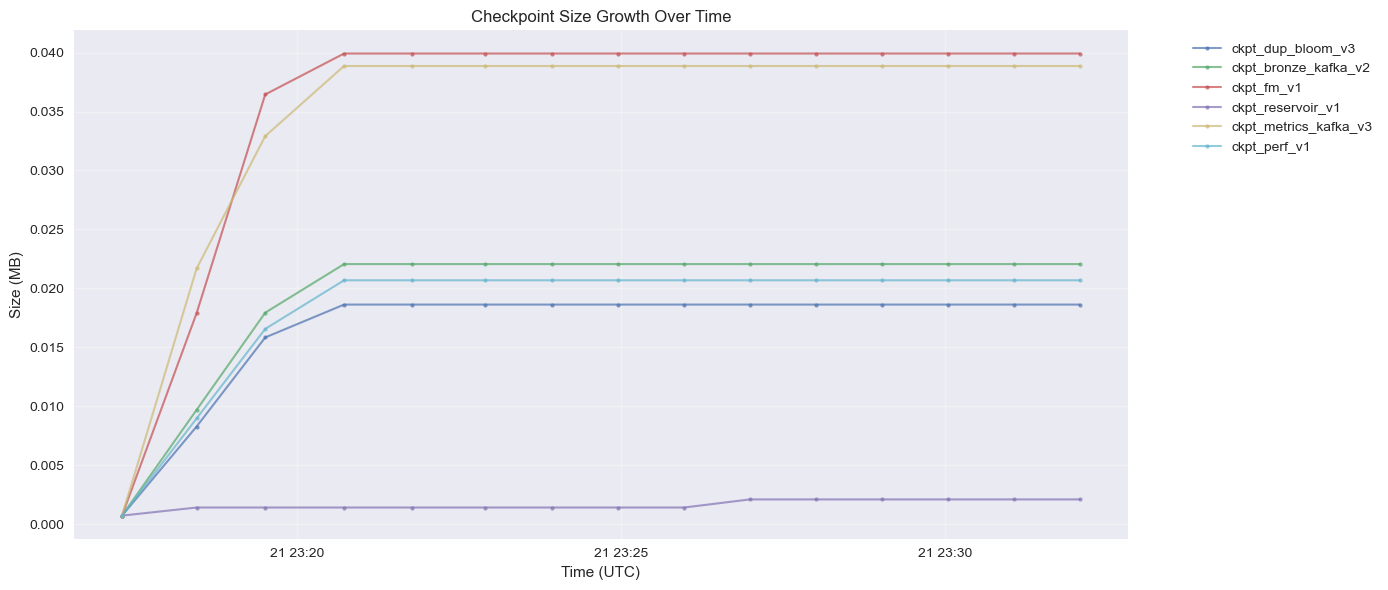


📦 Latest Checkpoint Sizes:
  _ckpt_bronze_kafka_v2: 0.02 MB
  _ckpt_dup_bloom_v3: 0.02 MB
  _ckpt_fm_v1: 0.04 MB
  _ckpt_metrics_kafka_v3: 0.04 MB
  _ckpt_perf_v1: 0.02 MB
  _ckpt_reservoir_v1: 0.00 MB


In [7]:
# Dashboard: Storage Tracking
if storage is not None and len(storage) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(14, 6))
    
    storage_sorted = storage.sort_values("timestamp")
    
    # Group by checkpoint and plot size over time
    for checkpoint in storage_sorted["checkpoint_name"].unique():
        checkpoint_data = storage_sorted[storage_sorted["checkpoint_name"] == checkpoint]
        label = checkpoint.lstrip("_") if checkpoint.startswith("_") else checkpoint
        ax.plot(
            checkpoint_data["timestamp"],
            checkpoint_data["size_mb"],
            label=label,
            alpha=0.7,
            linewidth=1.5,
            marker="o",
            markersize=3,
        )
    
    ax.set_ylabel("Size (MB)")
    ax.set_xlabel("Time (UTC)")
    ax.set_title("Checkpoint Size Growth Over Time")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    latest = storage_sorted.groupby("checkpoint_name").last()
    print("\n📦 Latest Checkpoint Sizes:")
    for checkpoint, row in latest.iterrows():
        print(f"  {checkpoint}: {row['size_mb']:.2f} MB")
else:
    print("Storage metrics not available")


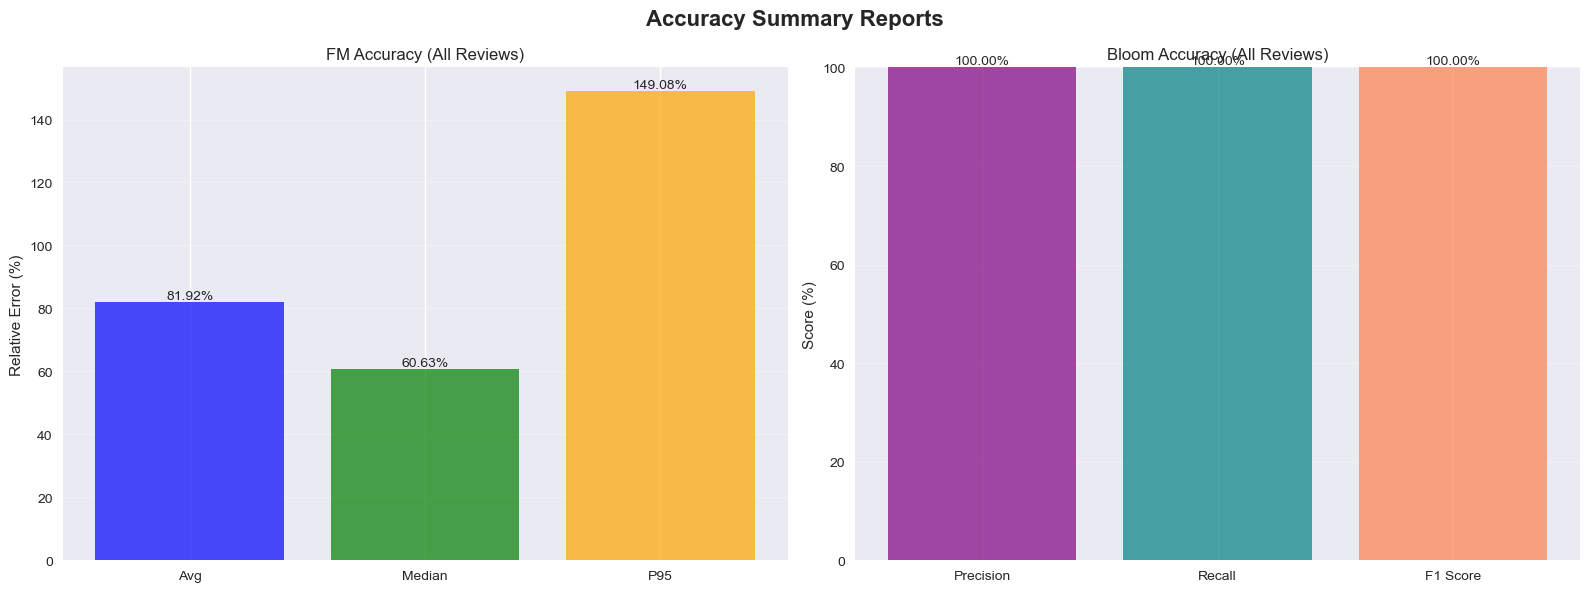


📊 Latest FM Accuracy Summary (All Reviews):
  Windows analyzed: 6
  Avg relative error: 81.92%
  Median relative error: 60.63%

🔍 Latest Bloom Accuracy Summary (All Reviews):
  Windows analyzed: 27
  Avg precision: 100.00%
  Avg recall: 100.00%
  Avg false positives: 0.0
  Avg false negatives: 0.0


In [8]:
# Dashboard: Accuracy Summaries
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Accuracy Summary Reports", fontsize=16, fontweight="bold")

# FM Accuracy Summary
ax = axes[0]
if fm_accuracy_all is not None and len(fm_accuracy_all) > 0:
    latest_fm = fm_accuracy_all.iloc[-1]
    metrics = ["avg_rel_error", "median_rel_error", "p95_rel_error"]
    labels = ["Avg", "Median", "P95"]
    values = [latest_fm.get(m, 0) * 100 for m in metrics]
    
    bars = ax.bar(labels, values, alpha=0.7, color=["blue", "green", "orange"])
    ax.set_ylabel("Relative Error (%)")
    ax.set_title("FM Accuracy (All Reviews)")
    ax.grid(True, alpha=0.3, axis="y")
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{val:.2f}%', ha='center', va='bottom')
else:
    ax.text(0.5, 0.5, "FM Accuracy data not available", 
           ha="center", va="center", transform=ax.transAxes)
    ax.set_title("FM Accuracy (All Reviews)")

# Bloom Accuracy Summary
ax = axes[1]
if bloom_accuracy_all is not None and len(bloom_accuracy_all) > 0:
    latest_bloom = bloom_accuracy_all.iloc[-1]
    metrics = ["avg_precision", "avg_recall", "avg_f1_score"]
    labels = ["Precision", "Recall", "F1 Score"]
    values = [latest_bloom.get(m, 0) * 100 for m in metrics]
    
    bars = ax.bar(labels, values, alpha=0.7, color=["purple", "teal", "coral"])
    ax.set_ylabel("Score (%)")
    ax.set_title("Bloom Accuracy (All Reviews)")
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, axis="y")
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{val:.2f}%', ha='center', va='bottom')
else:
    ax.text(0.5, 0.5, "Bloom Accuracy data not available", 
           ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Bloom Accuracy (All Reviews)")

plt.tight_layout()
plt.show()

# Print accuracy summaries
if fm_accuracy_all is not None and len(fm_accuracy_all) > 0:
    print("\n📊 Latest FM Accuracy Summary (All Reviews):")
    latest = fm_accuracy_all.iloc[-1]
    print(f"  Windows analyzed: {latest.get('windows_with_exact', 'N/A')}")
    print(f"  Avg relative error: {latest.get('avg_rel_error', 0):.2%}")
    print(f"  Median relative error: {latest.get('median_rel_error', 0):.2%}")

if bloom_accuracy_all is not None and len(bloom_accuracy_all) > 0:
    print("\n🔍 Latest Bloom Accuracy Summary (All Reviews):")
    latest = bloom_accuracy_all.iloc[-1]
    print(f"  Windows analyzed: {latest.get('windows_analyzed', 'N/A')}")
    print(f"  Avg precision: {latest.get('avg_precision', 0):.2%}")
    print(f"  Avg recall: {latest.get('avg_recall', 0):.2%}")
    print(f"  Avg false positives: {latest.get('avg_false_positives', 0):.1f}")
    print(f"  Avg false negatives: {latest.get('avg_false_negatives', 0):.1f}")


In [9]:
# MinHash LSH + Differential Privacy sanity check
from pathlib import Path

import pandas as pd
from IPython.display import display


def _resolve_delta_root() -> Path:
    """Look for the delta/ folder relative to common notebook launch points."""
    candidates = [
        Path.cwd() / "delta",
        Path.cwd().parent / "delta",
        Path("/Users/andreah/Documents/GitHub/228_Project/delta"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not locate delta/ directory; run from repo root")


def _read_recent_parquet(dir_path: Path, max_files: int = 20) -> pd.DataFrame:
    if not dir_path.exists():
        return pd.DataFrame()
    files = sorted(dir_path.glob("*.parquet"))
    if not files:
        return pd.DataFrame()
    subset = files[-max_files:]
    return pd.concat((pd.read_parquet(f) for f in subset), ignore_index=True)


delta_root = _resolve_delta_root()
raw_df = _read_recent_parquet(delta_root / "dup_lsh_raw")
dp_df = _read_recent_parquet(delta_root / "dup_lsh_dp")

if raw_df.empty or dp_df.empty:
    print(
        "Run spark/sketch_lsh_dp.py to generate dup_lsh_raw and dup_lsh_dp before executing this cell."
    )
else:
    dp_df["processing_time"] = pd.to_datetime(dp_df["processing_time"])
    dp_df["approx_jaccard"] = pd.to_numeric(dp_df["approx_jaccard"], errors="coerce")
    insight = (
        dp_df.groupby("business_id")
        .agg(
            total_pairs=("review_id", "count"),
            avg_jaccard=("approx_jaccard", "mean"),
            max_noisy=("noisy_frequency", "max"),
        )
        .sort_values("total_pairs", ascending=False)
        .head(5)
    )
    display(insight)

    top_pair = dp_df.sort_values("approx_jaccard", ascending=False).head(1).iloc[0]
    print(
        "Most suspicious pair: review {rid} ↔ {sid} (business {bid}) with Jaccard≈{jac:.2f} and noisy freq≈{freq:.1f}.".format(
            rid=top_pair["review_id"],
            sid=top_pair["similar_review_id"],
            bid=top_pair["business_id"],
            jac=top_pair["approx_jaccard"],
            freq=top_pair["noisy_frequency"],
        )
    )



,total_pairs,avg_jaccard,max_noisy
business_id,,,
r5dUIJJwaChqvIjGkUJtfw,55,0.850994,10.793879


Most suspicious pair: review n3z5dkyayq7YYDsBS9UYJQ ↔ OhbVrpoiVgRV5IfLBcbfno (business r5dUIJJwaChqvIjGkUJtfw) with Jaccard≈0.98 and noisy freq≈8.9.


In [10]:
import pandas as pd
from pathlib import Path

bug_dir = Path("/Users/andreah/Documents/GitHub/228_Project/delta/dup_lsh_bug_summary")
files = sorted(bug_dir.glob("*.parquet"))
if files:
    bug_df = pd.concat(pd.read_parquet(p) for p in files[-5:])
    display(bug_df.sort_values("bug_pair_count", ascending=False).head(10))
else:
    print("No bug summary rows yet.")

,business_id,bug_pair_count,avg_review_stars,avg_similar_stars,avg_jaccard,avg_star_gap,max_noisy_frequency,low_star_pair_rate,keyword_coverage
0,r5dUIJJwaChqvIjGkUJtfw,55,1.454545,1.454545,0.850994,0.545455,10.793879,1.0,5


In [11]:
from pathlib import Path
import pandas as pd

root = Path("/Users/andreah/Documents/GitHub/228_Project")

raw_files = sorted((root / "delta/dup_lsh_raw").glob("*.parquet"))
dp_files = sorted((root / "delta/dup_lsh_dp").glob("*.parquet"))

if not raw_files or not dp_files:
    print("Need dup_lsh_raw and dup_lsh_dp first (run sketch_lsh_dp.py).")
else:
    raw_df = pd.concat(pd.read_parquet(p) for p in raw_files[-5:])
    dp_df = pd.concat(pd.read_parquet(p) for p in dp_files[-5:])

    # exact (pre‑DP) counts from raw pairs
    exact_counts = (
        raw_df.groupby(["similar_review_id", "similar_business_id"])
              .size()
              .reset_index(name="exact_frequency")
    )

    # join with DP table to see noisy vs exact
    compare = (
        dp_df[["similar_review_id", "similar_business_id", "noisy_frequency"]]
        .drop_duplicates()
        .merge(exact_counts,
               on=["similar_review_id", "similar_business_id"],
               how="left")
    )
    compare["noise"] = compare["noisy_frequency"] - compare["exact_frequency"]
    display(compare.sort_values("exact_frequency", ascending=False))

,similar_review_id,similar_business_id,noisy_frequency,exact_frequency,noise
0,Zuzren68K4TunPFz46PDjq,r5dUIJJwaChqvIjGkUJtfw,4.330572,5,-0.669428
1,PPgdzUvZ3gpmmICiBlrDp3,r5dUIJJwaChqvIjGkUJtfw,9.263001,5,4.263001
2,OhbVrpoiVgRV5IfLBcbfno,r5dUIJJwaChqvIjGkUJtfw,8.869614,5,3.869614
3,WIXiiQE8JkqH3MB9n7IWUS,r5dUIJJwaChqvIjGkUJtfw,7.502091,4,3.502091
4,aeTOdoe5c3veGprQFnIiU7,r5dUIJJwaChqvIjGkUJtfw,8.020941,4,4.020941
5,jOkYRBMeyyMDHqJ38aRUhR,r5dUIJJwaChqvIjGkUJtfw,4.738729,4,0.738729
6,6g3Ot1OGMmjxWkI9X7H6aM,r5dUIJJwaChqvIjGkUJtfw,10.793879,4,6.793879
7,kd9Gf2leMeR3pzh84KpLMc,r5dUIJJwaChqvIjGkUJtfw,3.848933,3,0.848933
8,n3z5dkyayq7YYDsBS9UYJQ,r5dUIJJwaChqvIjGkUJtfw,0.638310,2,-1.361690
9,o3gyrDO1xkxwnQrS7RPeMO,r5dUIJJwaChqvIjGkUJtfw,0.895497,1,-0.104503


In [57]:
from pathlib import Path
import pandas as pd

print("CWD:", Path.cwd())
print("PROJECT_ROOT:", PROJECT_ROOT)
print("FM exists:", (PROJECT_ROOT / "delta" / "accuracy_fm_summary").exists())
print("Bloom exists:", (PROJECT_ROOT / "delta" / "accuracy_bloom_summary").exists())

fm_debug = pd.read_parquet(PROJECT_ROOT / "delta" / "accuracy_fm_summary")
bloom_debug = pd.read_parquet(PROJECT_ROOT / "delta" / "accuracy_bloom_summary")

CWD: /Users/andreah/Documents/GitHub/228_Project/notebooks
PROJECT_ROOT: /Users/andreah/Documents/GitHub/228_Project
FM exists: True
Bloom exists: True
